# Baseline Model 

This notebook trains a baseline Logistic Regression model using the preprocessing pipeline developed in the previous notebook. The objective is to establish a baseline performance for comparison with more advanced models and imbalance-handling techniques.

## 1. Import libaries

In [16]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( 
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay

## 2. Load raw data

In [17]:
data_path = "../data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)
df = df.drop(columns=['id'])
df = df[df["gender"] != "Other"]

## 3. Tran/Test Split

In [18]:
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Build the preprocessing pipeline

In [19]:
numeric_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

binary_features = [
    "hypertension",
    "heart_disease"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

## 5. Build the modeling pipeline

The preprocessing pipeline is combined with the classifier into a single scikit-learn Pipeline. This ensures that all preprocessing steps are applied consistently during both training and prediction while preventing data leakage.

#### Why Logistic Regression?

Logistic Regression is a widely used baseline classifier for binary classification problems. It is computationally efficient, easy to interpret, and provides a strong benchmark before evaluating more complex machine learning models.

In [20]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [21]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['gender','age','hypertension',...,'avg_glucose_level','bmi', 'smoking_status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

## 6. Generate Predictions

In [22]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## 7. Model Evaluation

### 7.1 Evaluation metrics table

In [29]:
# Calculate evaluation metrics
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

metrics["Score"] = metrics["Score"].round(3)
metrics

,Metric,Score
0,Accuracy,0.952
1,Precision,1.000
2,Recall,0.020
3,F1-score,0.039
4,ROC-AUC,0.839


#### Interpretation

* Accuracy is high (95.2%) due to the overwhelming majority of non-stroke cases.
* Precision is perfect because every predicted stroke case was truly positive.
* Recall is extremely low (2%), indicating that most stroke cases were missed.
* The ROC-AUC of 0.839 suggests that the model is able to rank patients by stroke risk reasonably well despite poor classification performance at the default decision threshold.

### 7.2 Classification report

In [30]:
report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
).transpose()

report.round(3)

,precision,recall,f1-score,support
0,0.952,1.000,0.975,972.000
1,1.000,0.020,0.039,50.000
accuracy,0.952,0.952,0.952,0.952
macro avg,0.976,0.510,0.507,1022.000
weighted avg,0.954,0.952,0.930,1022.000


### Baseline Model Performance

The baseline Logistic Regression model was evaluated using multiple metrics. Because the dataset is highly imbalanced, accuracy alone is not sufficient for assessing model performance. Greater emphasis is placed on recall and ROC-AUC, as identifying stroke cases is more important than maximizing overall accuracy.

### 7.3 Confusion Matrix

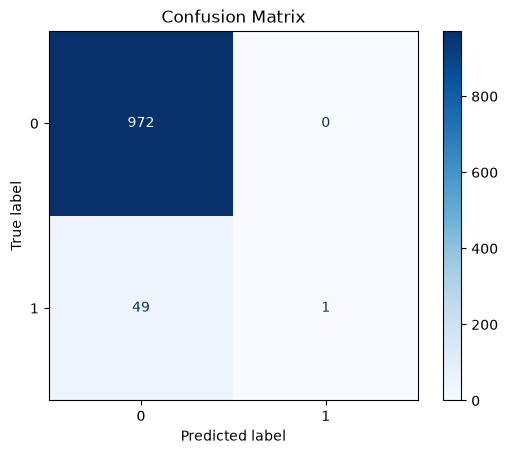

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [26]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[972   0]
 [ 49   1]]


The confusion matrix shows that the model correctly classified 972 of 972 non-stroke patients but detected only 1 of the 50 stroke patients. While false positives were eliminated, the large number of false negatives makes the model unsuitable for clinical screening, where failing to identify stroke patients could have serious consequences.

### 7.4 ROC Curve

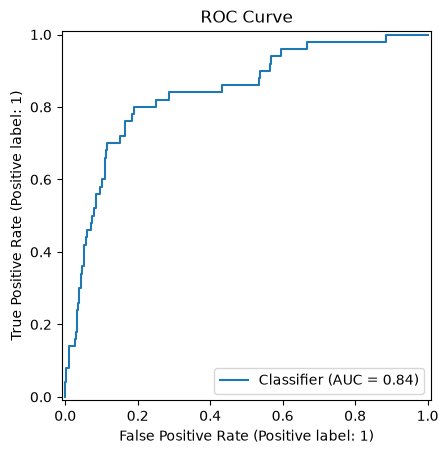

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

In [28]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8393827160493826


Although the classifier predicts very few positive cases using the default threshold of 0.5, the ROC-AUC of 0.839 indicates that the model has learned useful relationships within the data. This suggests that improving the decision threshold or addressing class imbalance may substantially improve recall without rebuilding the entire model.

### Interpretation

Although the baseline Logistic Regression model achieved an accuracy of approximately 95%, the confusion matrix reveals that it correctly identified only 1 of the 50 stroke cases. The model is heavily biased toward predicting the majority class, resulting in a recall of only 2%. This demonstrates that accuracy is not an appropriate metric for highly imbalanced datasets and motivates exploring techniques such as class weighting, resampling, or threshold adjustment in subsequent models.


### Next Steps

The baseline Logistic Regression model demonstrates that the preprocessing pipeline is functioning correctly and that the model has learned meaningful patterns (ROC-AUC = 0.839). However, the extremely low recall highlights the impact of severe class imbalance. The next notebook will investigate strategies to improve minority class detection, including class weighting, resampling techniques, and alternative decision thresholds.